=== CALIBRATION DATASET SUMMARY ===
Total rows: 14916
Unique concentrations: [np.float64(0.0), np.float64(4.60417619265356), np.float64(6.90626428898034), np.float64(10.3593964334705), np.float64(15.5390946502058), np.float64(23.3086419753086), np.float64(34.962962962963), np.float64(52.4444444444445), np.float64(78.6666666666667), np.float64(118.0), np.float64(236.0)] nM
Total wells analyzed: 33

=== BLANK & NOISE METRICS ===
Blank mean signal       : 3149.32 RFU
Blank standard dev (σ)  : 91.36 RFU
Limit of Detection (LOD): 274.08 RFU (3σ)
Limit of Quant. (LOQ)   : 913.61 RFU (10σ)

=== LINEAR CALIBRATION PARAMETERS (FITTED ON MEANS) ===
Alpha (F_inf slope)    : 43.8234 RFU/nM | R² = 0.9495
k_on,obs (V0 slope)    : 0.5849 RFU/(nM·min) | R² = 0.9838

=== KINETIC INVARIANCE STATISTICAL TEST ===
Kruskal-Wallis H-statistic : 6.8533
p-value                     : 4.44309e-01
Result                      : Invariance VALIDATED (p > 0.05)


C:\Users\ForzaPC\AppData\Local\Temp\ipykernel_23160\1089692437.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


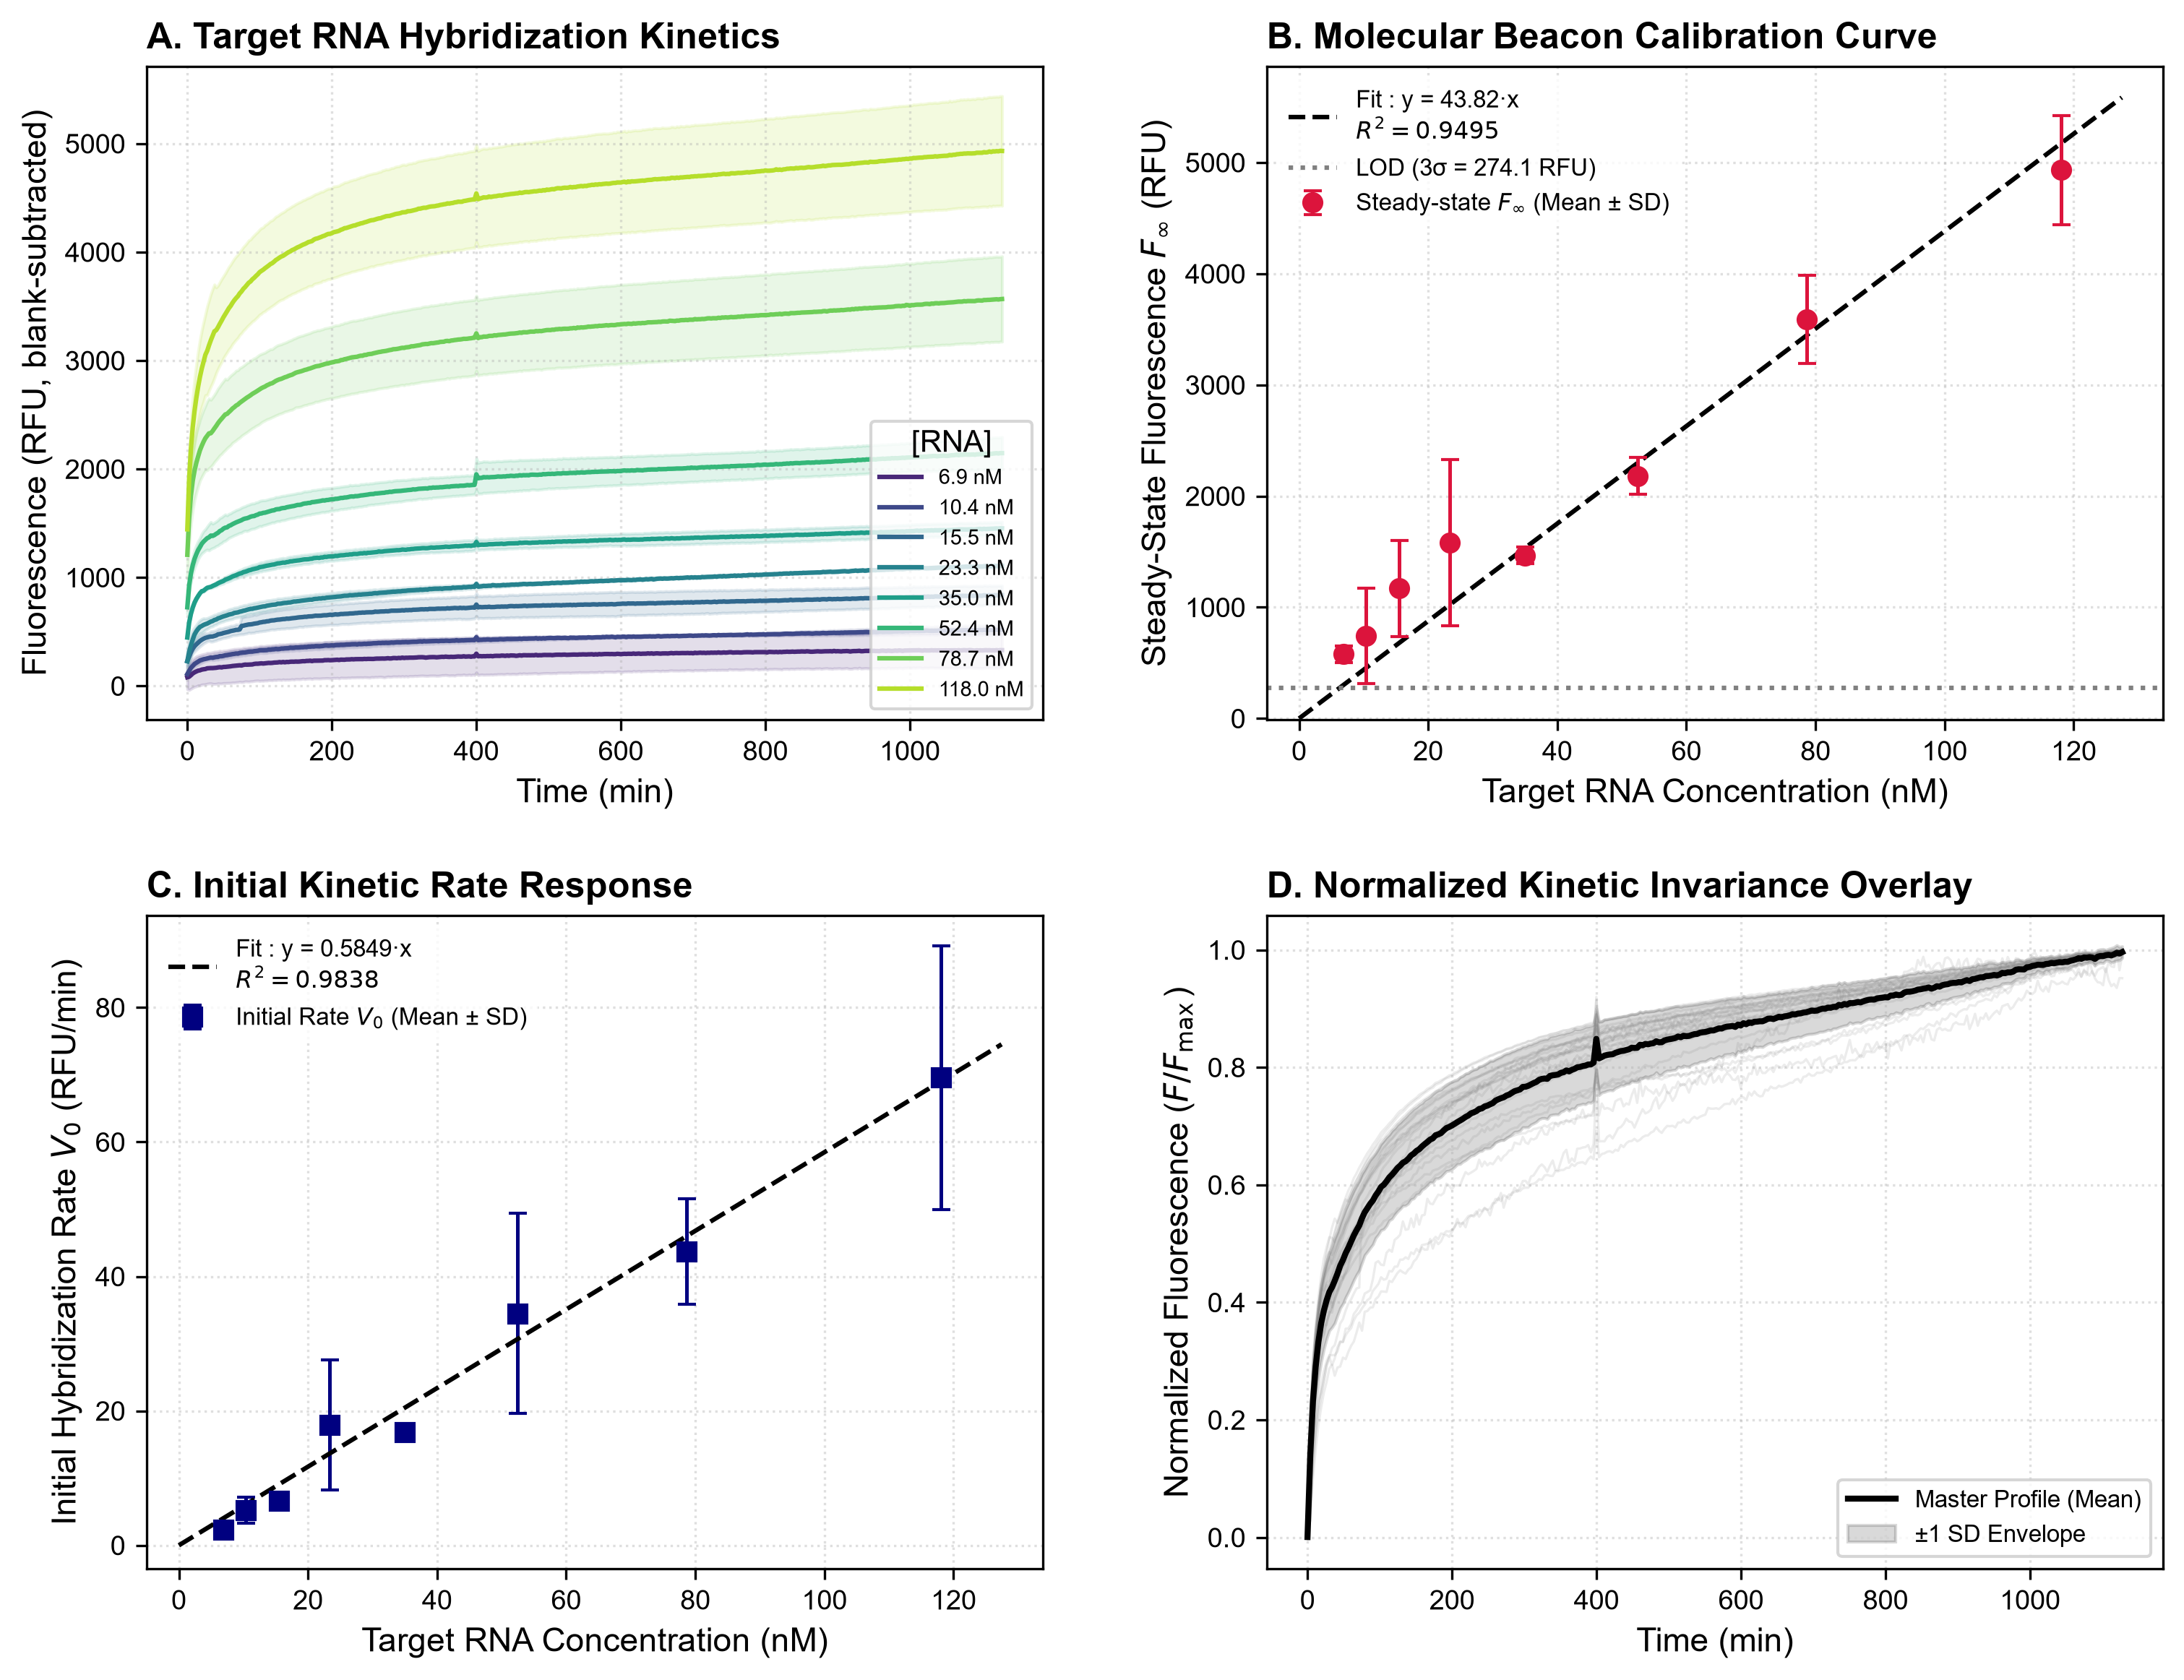


✅ Figure 1 exported successfully: 'figure_1_calibration_deconvolution.pdf' and '.png'


In [10]:
# ==============================================================================
# SECTION 1: MOLECULAR BEACON CALIBRATION & SIGNAL DECONVOLUTION
# Author: Molecular Transcription Group
# Purpose: Quantify MB hybridization kinetics, determine the RFU-to-nM conversion
#          slope (alpha), validate kinetic shape invariance (Kruskal-Wallis),
#          and generate publication-ready calibration figures.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import seaborn as sns

# Configure publication-quality plot parameters (Nature/ACS guidelines)
plt.rcParams.update({
    'font.size': 10,
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# ------------------------------------------------------------------------------
# 1. LOAD CLEAN CALIBRATION DATA
# ------------------------------------------------------------------------------

# Read the tidied calibration dataset from the previous pipeline stage
df_calib = pd.read_csv(r"C:\\Users\\ForzaPC\\Desktop\\repo\\data\\calibrations\\calibration_data_clean.csv")

# Convert cycle to time in minutes (2.5 min interval = 150 seconds)
CYCLE_INTERVAL_SEC = 150
TIME_UNIT_DIVISOR = 60  # convert to minutes

df_calib['Time_min'] = df_calib['Cycle'] * CYCLE_INTERVAL_SEC / TIME_UNIT_DIVISOR

print("=== CALIBRATION DATASET SUMMARY ===")
print(f"Total rows: {len(df_calib)}")
print(f"Unique concentrations: {sorted(df_calib['[Target_RNA] (nM)'].unique())} nM")
print(f"Total wells analyzed: {df_calib['Well'].nunique()}")

# ------------------------------------------------------------------------------
# 2. BLANK SUBTRACTION & NOISE CHARACTERIZATION (LOD / LOQ)
# ------------------------------------------------------------------------------

# Extract blank wells ([Target_RNA] == 0 nM)
df_blank = df_calib[df_calib['[Target_RNA] (nM)'] == 0.0]

blank_mean = df_blank['RFU'].mean()
blank_std = df_blank['RFU'].std(ddof=1)

# Limit of Detection (LOD = 3*sigma) and Limit of Quantification (LOQ = 10*sigma)
LOD_signal = 3 * blank_std
LOQ_signal = 10 * blank_std

print("\n=== BLANK & NOISE METRICS ===")
print(f"Blank mean signal       : {blank_mean:.2f} RFU")
print(f"Blank standard dev (σ)  : {blank_std:.2f} RFU")
print(f"Limit of Detection (LOD): {LOD_signal:.2f} RFU (3σ)")
print(f"Limit of Quant. (LOQ)   : {LOQ_signal:.2f} RFU (10σ)")

# Apply Blank Correction across the entire calibration dataset
df_calib['RFU_corr'] = df_calib['RFU'] - blank_mean

# ------------------------------------------------------------------------------
# 3. KINETIC MODEL FITTING (BIPHASIC / ANCHORED HYBRIDIZATION MODEL)
# ------------------------------------------------------------------------------

def bi_exponential_model(t, F0, A_fast, A_slow, k_fast, k_slow):
    """
    Bi-exponential hybridization model anchored at t=0:
    F(t) = F0 + A_fast * (1 - exp(-k_fast * t)) + A_slow * (1 - exp(-k_slow * t))
    """
    return F0 + A_fast * (1.0 - np.exp(-k_fast * t)) + A_slow * (1.0 - np.exp(-k_slow * t))

def fit_well_kinetics(time_vec, rfu_vec):
    """Fits bi-exponential kinetics to individual well data and extracts steady-state F_inf and V0."""
    mask = ~np.isnan(rfu_vec)
    t_clean, y_clean = time_vec[mask], rfu_vec[mask]
    
    f_init = y_clean[0]
    f_max = np.max(y_clean)
    delta_f = max(f_max - f_init, 1e-3)
    
    # Parameter initial guesses & strict physical boundary conditions
    p0 = [f_init, delta_f * 0.5, delta_f * 0.5, 0.1, 0.01]
    bounds = (
        [f_init * 0.7, 0, 0, 0, 0],
        [f_init * 1.3, delta_f * 2.0, delta_f * 2.0, 50.0, 50.0]
    )
    
    popt, _ = curve_fit(bi_exponential_model, t_clean, y_clean, p0=p0, bounds=bounds, maxfev=100000)
    
    F0, A_fast, A_slow, k_fast, k_slow = popt
    if k_fast < k_slow:
        k_fast, k_slow = k_slow, k_fast
        A_fast, A_slow = A_slow, A_fast
        
    F_inf = F0 + A_fast + A_slow
    V0 = (A_fast * k_fast) + (A_slow * k_slow)  # Analytical derivative dF/dt at t=0
    
    return F_inf, V0, F0, k_fast, k_slow

# Fit per well and aggregate results
well_fit_results = []
concentrations = sorted([c for c in df_calib['[Target_RNA] (nM)'].unique() if c > 0])

for conc in concentrations:
    df_c = df_calib[df_calib['[Target_RNA] (nM)'] == conc]
    wells = df_c['Well'].unique()
    
    for w in wells:
        df_w = df_c[df_c['Well'] == w].sort_values('Time_min')
        t_vec = df_w['Time_min'].values
        rfu_vec = df_w['RFU_corr'].values
        
        try:
            F_inf, V0, F0, k_fast, k_slow = fit_well_kinetics(t_vec, rfu_vec)
            well_fit_results.append({
                'Well': w,
                '[Target_RNA] (nM)': conc,
                'F_inf': F_inf,
                'V0': V0,
                'F0': F0,
                'k_fast': k_fast,
                'k_slow': k_slow
            })
        except Exception:
            continue

df_fits = pd.DataFrame(well_fit_results)

# ------------------------------------------------------------------------------
# 4. CALIBRATION CURVE & LINEAR REGRESSION ON MEANS (PASSING THROUGH 0,0)
# ------------------------------------------------------------------------------

# Filter out high-concentration saturation (> 200 nM) and low points (< 5 nM)
SATURATION_THRESHOLD_NM = 200
df_calib_linear = df_fits[
    (df_fits['[Target_RNA] (nM)'] < SATURATION_THRESHOLD_NM) & 
    (df_fits['[Target_RNA] (nM)'] > 5.0)
]

# Calculate mean and SD per concentration
df_stats = df_calib_linear.groupby('[Target_RNA] (nM)').agg(
    F_inf_mean=('F_inf', 'mean'),
    F_inf_std=('F_inf', lambda x: x.std(ddof=1) if len(x) > 1 else 0.0),
    V0_mean=('V0', 'mean'),
    V0_std=('V0', lambda x: x.std(ddof=1) if len(x) > 1 else 0.0)
).reset_index()

# Extraction des arrays de moyennes
x_data = df_stats['[Target_RNA] (nM)'].values
Finf_y = df_stats['F_inf_mean'].values
V0_y = df_stats['V0_mean'].values

def droite_origine(x, a):
    """Modèle y = a * x (passage forcé par l'origine)"""
    return a * x

def calcul_r2_origine(x, y, a):
    """Calcul du R² pour régression contrainte à l'origine"""
    y_pred = droite_origine(x, a)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - (ss_res / ss_tot)

# Regression sur F_inf (moyennes)
popt_F, _ = curve_fit(droite_origine, x_data, Finf_y)
alpha_slope = popt_F[0]
r2_score = calcul_r2_origine(x_data, Finf_y, alpha_slope)

# Regression sur V0 (moyennes)
popt_V, _ = curve_fit(droite_origine, x_data, V0_y)
slope_v = popt_V[0]
r2_score_v = calcul_r2_origine(x_data, V0_y, slope_v)

print("\n=== LINEAR CALIBRATION PARAMETERS (FITTED ON MEANS) ===")
print(f"Alpha (F_inf slope)    : {alpha_slope:.4f} RFU/nM | R² = {r2_score:.4f}")
print(f"k_on,obs (V0 slope)    : {slope_v:.4f} RFU/(nM·min) | R² = {r2_score_v:.4f}")

# ------------------------------------------------------------------------------
# 5. KINETIC SHAPE INVARIANCE TEST (KRUSKAL-WALLIS)
# ------------------------------------------------------------------------------

t_common = np.linspace(df_calib['Time_min'].min(), df_calib['Time_min'].max(), 300)
normalized_profiles = []
conc_labels = []

for conc in df_stats['[Target_RNA] (nM)'].unique():
    df_c = df_calib[df_calib['[Target_RNA] (nM)'] == conc]
    for w in df_c['Well'].unique():
        df_w = df_c[df_c['Well'] == w].sort_values('Time_min')
        sig = df_w['RFU_corr'].values
        if len(sig) == 0: continue
        
        s_min, s_max = np.min(sig), np.max(sig)
        if s_max == s_min: continue
        sig_norm = (sig - s_min) / (s_max - s_min)
        
        sig_interp = np.interp(t_common, df_w['Time_min'].values, sig_norm)
        normalized_profiles.append(sig_interp)
        conc_labels.append(conc)

mat_norm = np.array(normalized_profiles)
master_curve = np.mean(mat_norm, axis=0)

residuals_by_conc = []
unique_concs = np.unique(conc_labels)
for conc in unique_concs:
    mask = (np.array(conc_labels) == conc)
    res = [np.mean(np.abs(profile - master_curve)) for profile in mat_norm[mask]]
    residuals_by_conc.append(res)

kw_stat, kw_pvalue = stats.kruskal(*residuals_by_conc)

print("\n=== KINETIC INVARIANCE STATISTICAL TEST ===")
print(f"Kruskal-Wallis H-statistic : {kw_stat:.4f}")
print(f"p-value                     : {kw_pvalue:.5e}")
print(f"Result                      : {'Invariance VALIDATED (p > 0.05)' if kw_pvalue > 0.05 else 'Invariance REJECTED (p <= 0.05)'}")

# ------------------------------------------------------------------------------
# 6. PUBLICATION FIGURE GENERATION
# ------------------------------------------------------------------------------

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# Panel A: Raw Hybridization Kinetics
ax_a = fig.add_subplot(gs[0, 0])
colors = sns.color_palette("viridis", len(df_stats))

for idx, conc in enumerate(df_stats['[Target_RNA] (nM)']):
    df_c = df_calib[df_calib['[Target_RNA] (nM)'] == conc]
    df_group = df_c.groupby('Time_min')['RFU_corr'].agg(['mean', 'std']).reset_index()
    
    ax_a.plot(df_group['Time_min'], df_group['mean'], label=f"{conc:.1f} nM", color=colors[idx], lw=1.5)
    ax_a.fill_between(df_group['Time_min'], df_group['mean'] - df_group['std'], 
                      df_group['mean'] + df_group['std'], color=colors[idx], alpha=0.15)

ax_a.set_xlabel("Time (min)")
ax_a.set_ylabel("Fluorescence (RFU, blank-subtracted)")
ax_a.set_title("A. Target RNA Hybridization Kinetics", fontweight='bold', loc='left')
ax_a.legend(title="[RNA]", fontsize=7, loc='lower right')
ax_a.grid(True, linestyle=':', alpha=0.4)

# Panel B: Linear Calibration Curve (F_inf vs Concentration)
ax_b = fig.add_subplot(gs[0, 1])
x_line = np.linspace(0, max(x_data) * 1.08, 100)

ax_b.errorbar(df_stats['[Target_RNA] (nM)'], df_stats['F_inf_mean'], yerr=df_stats['F_inf_std'],
              fmt='o', color='crimson', ecolor='crimson', elinewidth=1.2, capsize=3,
              label="Steady-state $F_{\\infty}$ (Mean ± SD)", zorder=3)

ax_b.plot(x_line, alpha_slope * x_line, 'k--', lw=1.5,
          label=f"Fit : y = {alpha_slope:.2f}·x\n$R^2 = {r2_score:.4f}$")

ax_b.axhline(LOD_signal, color='gray', linestyle=':', label=f"LOD (3σ = {LOD_signal:.1f} RFU)")
ax_b.set_xlabel("Target RNA Concentration (nM)")
ax_b.set_ylabel("Steady-State Fluorescence $F_{\\infty}$ (RFU)")
ax_b.set_title("B. Molecular Beacon Calibration Curve", fontweight='bold', loc='left')
ax_b.set_xlim(left=-5)
ax_b.set_ylim(bottom=-10)
ax_b.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax_b.grid(True, linestyle=':', alpha=0.4)

# Panel C: Initial Hybridization Rate (V0 vs Concentration)
ax_c = fig.add_subplot(gs[1, 0])

ax_c.errorbar(df_stats['[Target_RNA] (nM)'], df_stats['V0_mean'], yerr=df_stats['V0_std'],
              fmt='s', color='navy', ecolor='navy', elinewidth=1.2, capsize=3,
              label="Initial Rate $V_0$ (Mean ± SD)")

ax_c.plot(x_line, slope_v * x_line, 'k--', lw=1.5,
          label=f"Fit : y = {slope_v:.4f}·x\n$R^2 = {r2_score_v:.4f}$")

ax_c.set_xlabel("Target RNA Concentration (nM)")
ax_c.set_ylabel("Initial Hybridization Rate $V_0$ (RFU/min)")
ax_c.set_title("C. Initial Kinetic Rate Response", fontweight='bold', loc='left')
ax_c.set_xlim(left=-5)
ax_c.set_ylim(bottom=-0.05 * max(df_stats['V0_mean']))
ax_c.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax_c.grid(True, linestyle=':', alpha=0.4)

# Panel D: Normalized Master Kinetic Profile & Variance Overlay
ax_d = fig.add_subplot(gs[1, 1])
std_master = np.std(mat_norm, axis=0, ddof=1)

for profile in mat_norm:
    ax_d.plot(t_common, profile, color='gray', alpha=0.15, lw=0.8)

ax_d.plot(t_common, master_curve, color='black', lw=2.0, label="Master Profile (Mean)")
ax_d.fill_between(t_common, master_curve - std_master, master_curve + std_master,
                  color='black', alpha=0.15, label="±1 SD Envelope")

ax_d.set_xlabel("Time (min)")
ax_d.set_ylabel("Normalized Fluorescence ($F / F_{\\max}$)")
ax_d.set_title("D. Normalized Kinetic Invariance Overlay", fontweight='bold', loc='left')
ax_d.legend(loc='lower right', frameon=True, facecolor='white')
ax_d.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

# Export Vector and Bitmap Figures
fig.savefig("C:\\Users\\ForzaPC\\Desktop\\repo\\figures\\figure_1_calibration_deconvolution.pdf", format='pdf', bbox_inches='tight')
fig.savefig("C:\\Users\\ForzaPC\\Desktop\\repo\\figures\\figure_1_calibration_deconvolution.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 1 exported successfully: 'figure_1_calibration_deconvolution.pdf' and '.png'")

=== DECONVOLUTION KERNEL SPECIFICATIONS ===
Time step (Δt)          : 2.5 min
Kernel points (N)       : 151
Steady-state response   : 35.08 RFU / nM

=== SYSTEM MATRIX SPECIFICATIONS ===
Toeplitz Matrix Shape   : (151, 151)
Condition Number        : 1.06e+20

=== PROCESSING EXPERIMENT: TL39 TX40 ===
Initial Blank Level : 3060.59 RFU

=== DECONVOLUTION SUMMARY (Exp: TL39 TX40 | Well: B4) ===
Max Raw Signal        : 6456.71 RFU
Max Corrected Signal  : 3351.79 RFU
Max Deconvolved RNA   : 103.24 nM


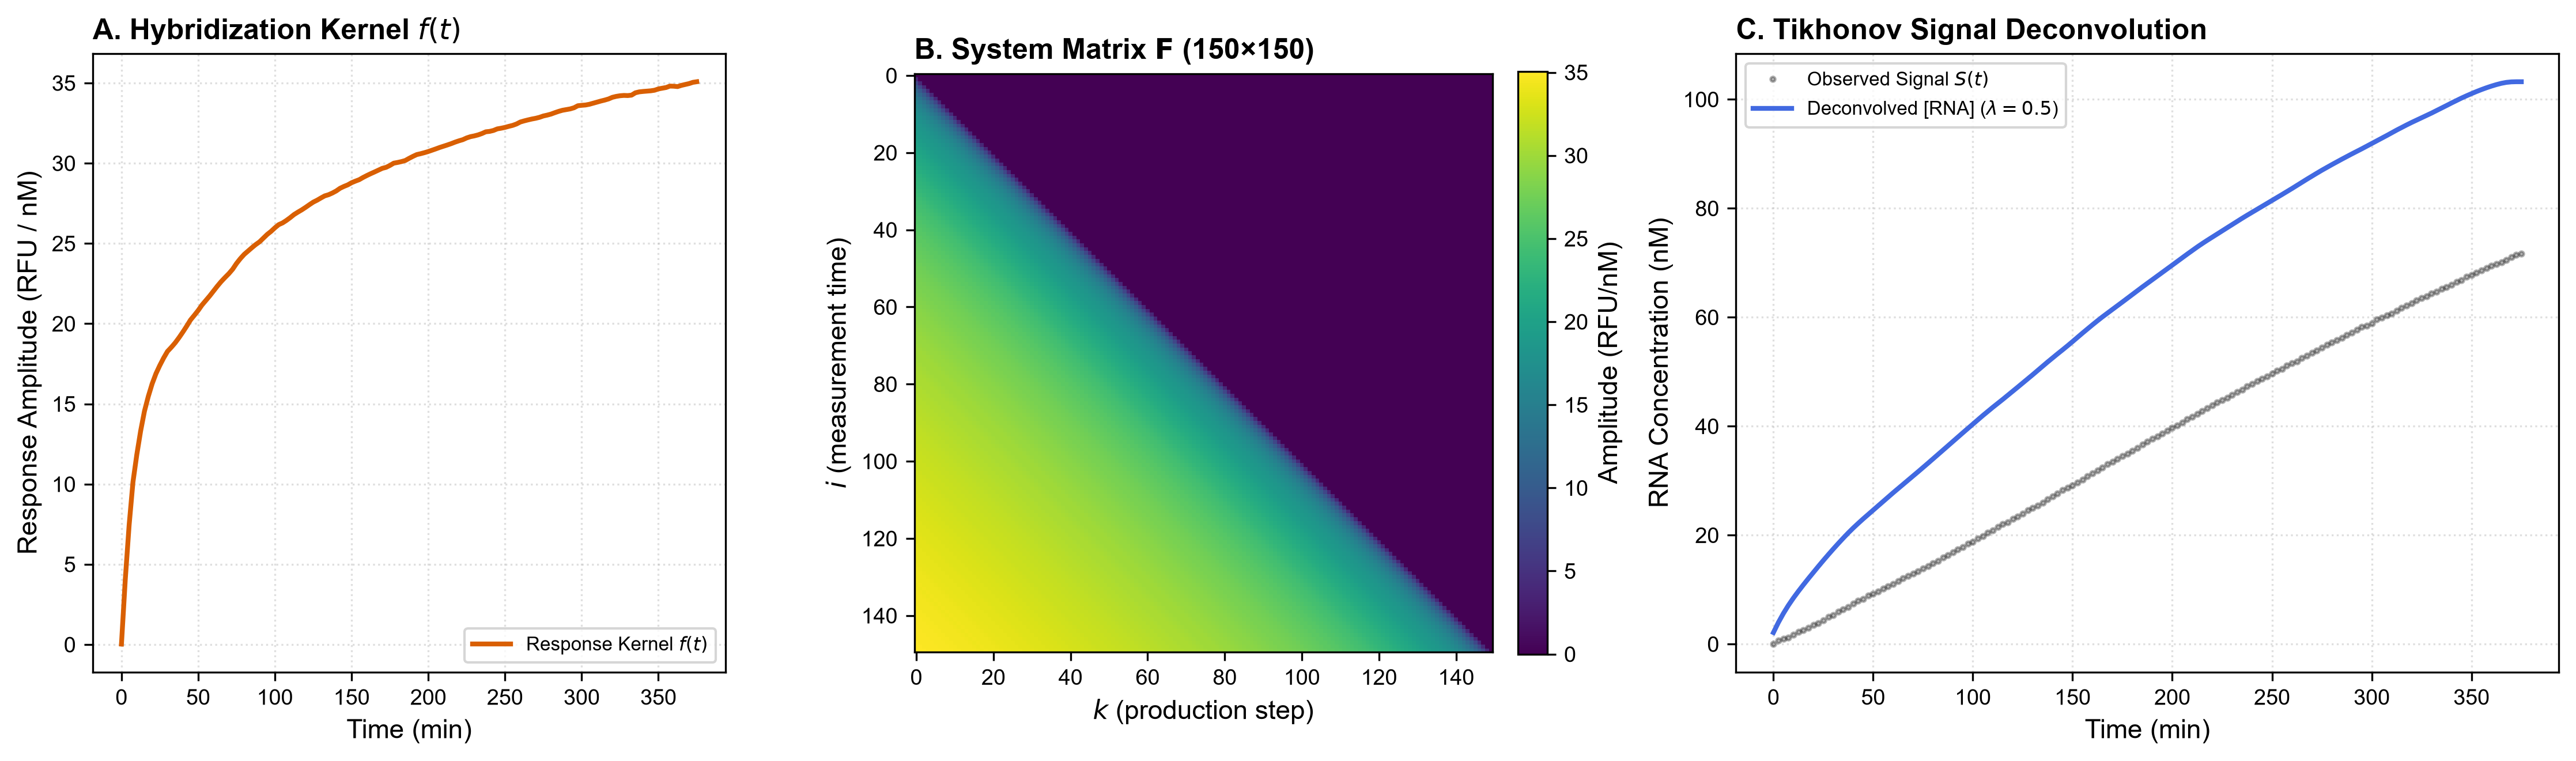

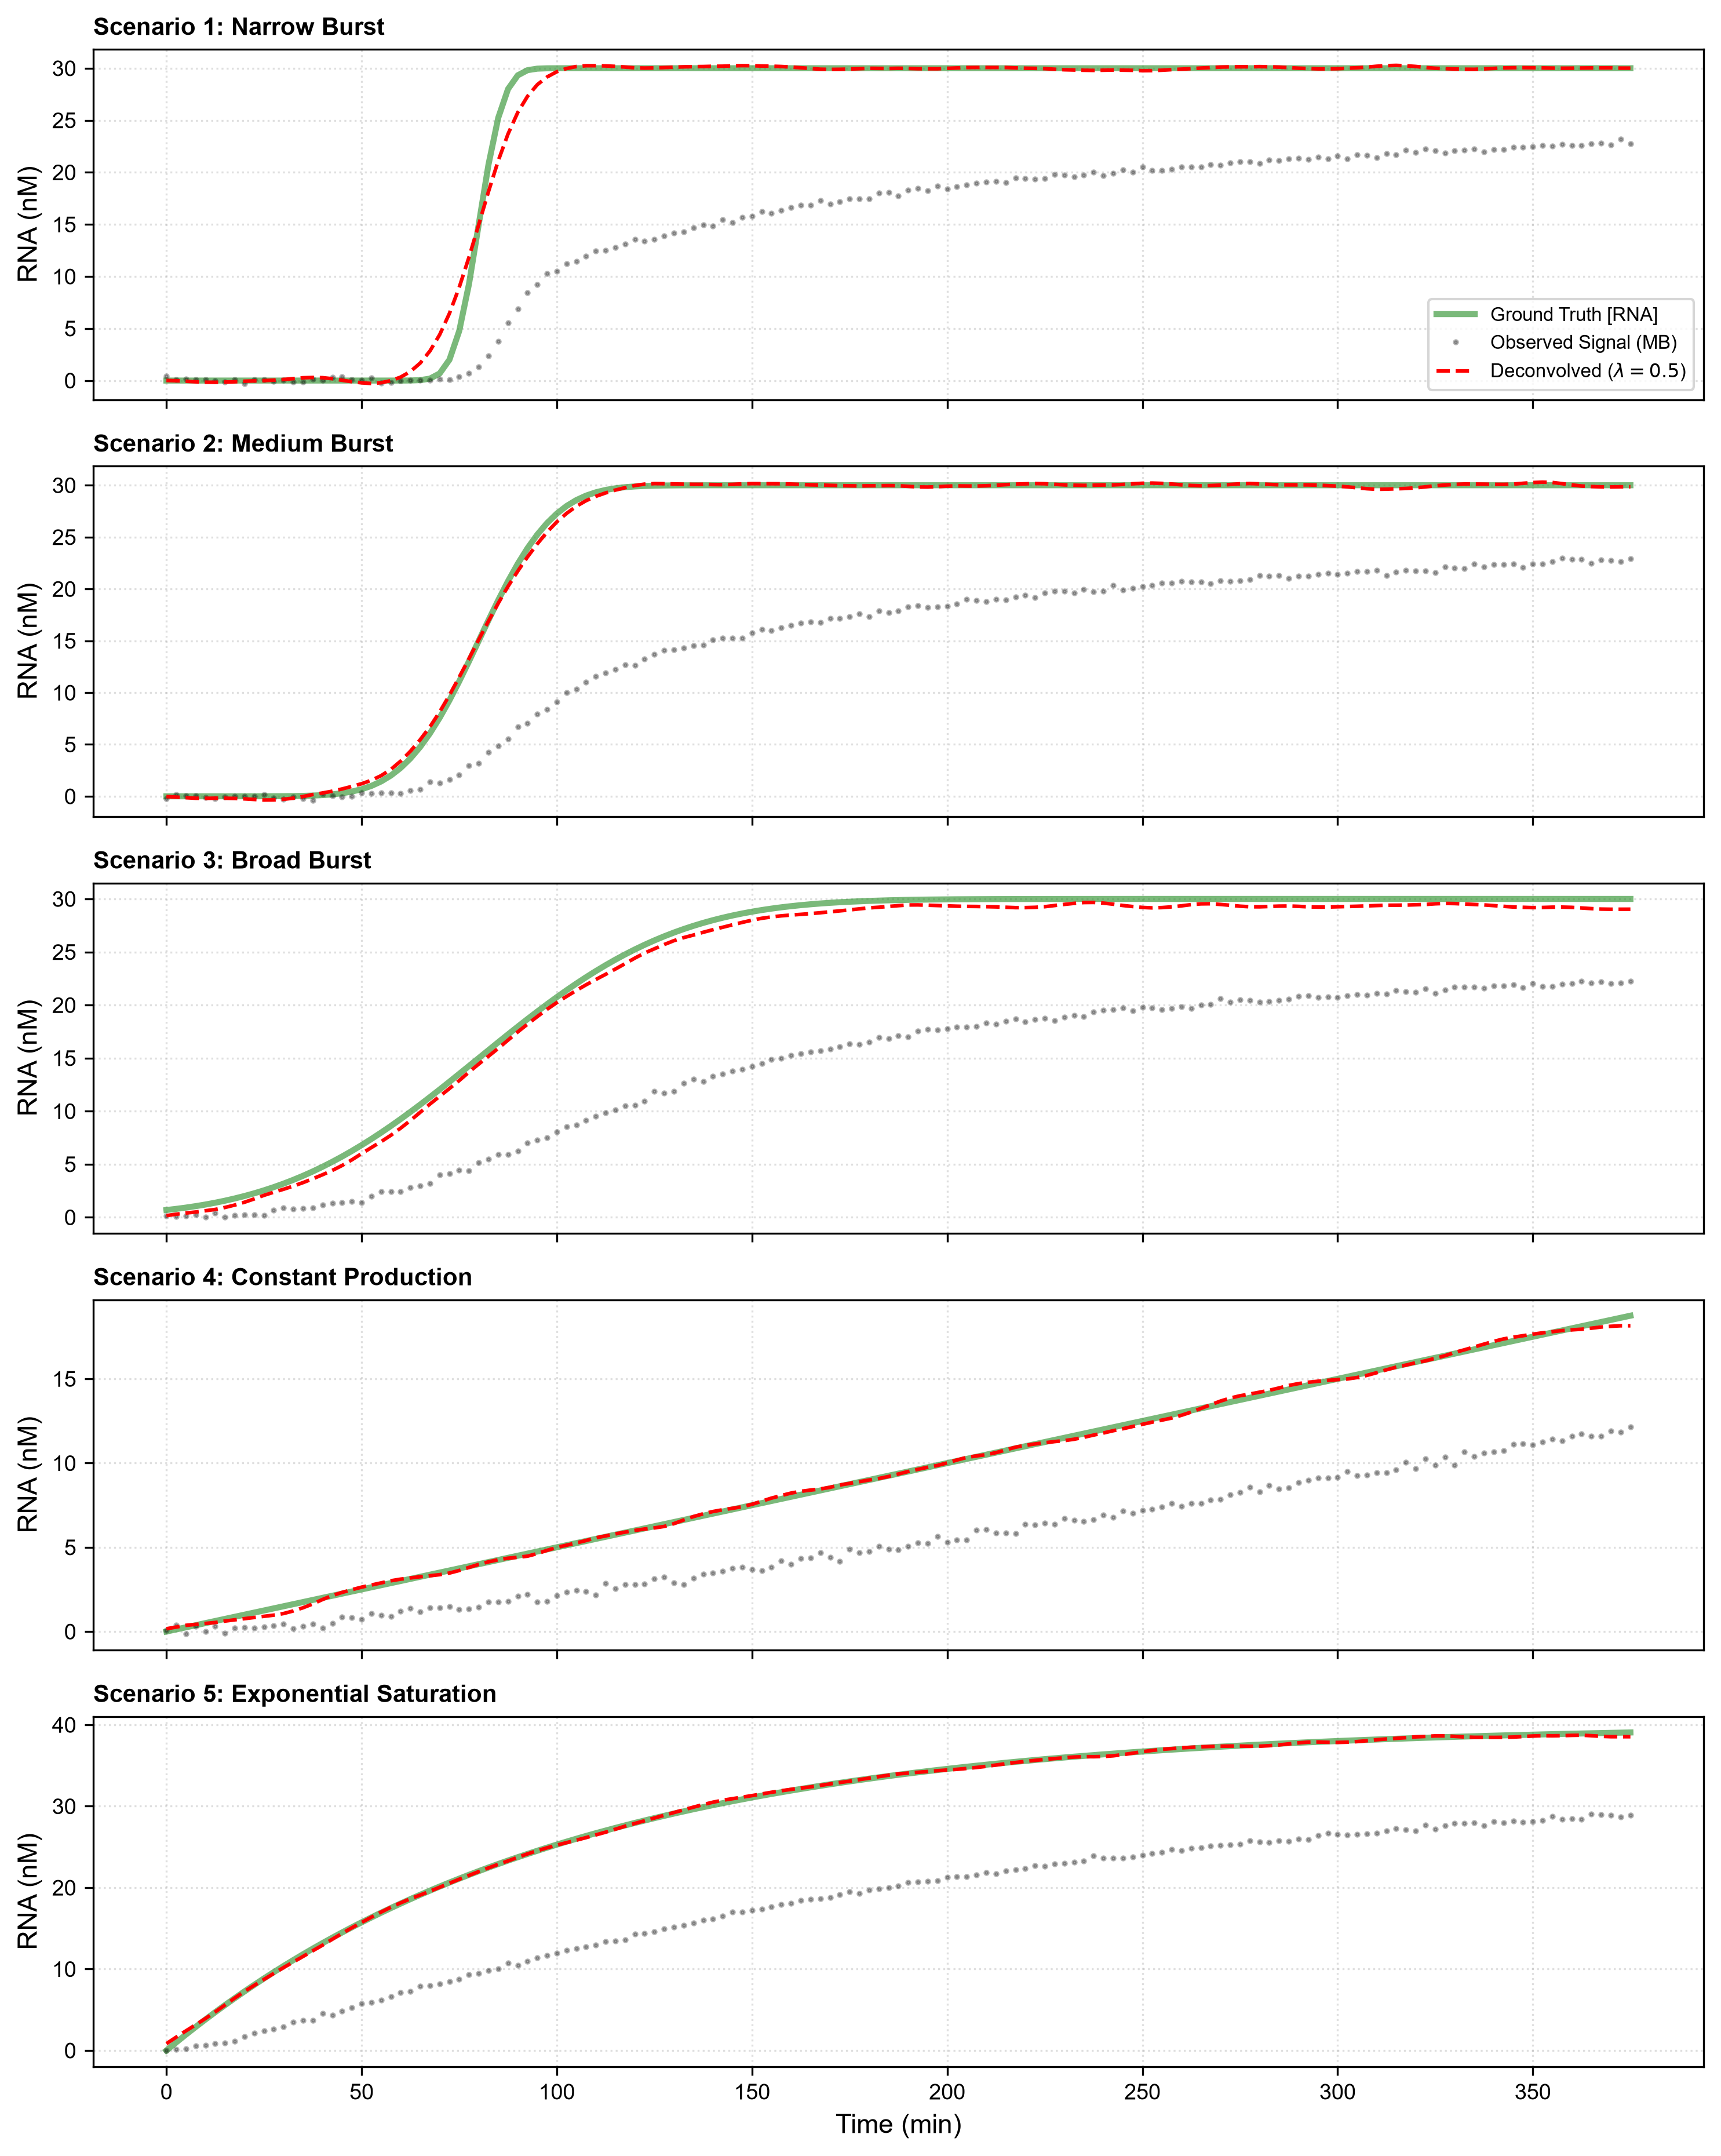


✅ Figure 2 exported successfully: 'figure_2_kernel_and_deconvolution.pdf' and 'figure_2_synthetic_benchmarking.pdf'


In [15]:
# ==============================================================================
# SECTION 2: MATRIX DECONVOLUTION & TIKHONOV REGULARIZATION
# Author: Molecular Transcription Group
# Purpose: Reconstruct real-time instant RNA production kinetics from Molecular
#          Beacon fluorescence using Toeplitz matrix deconvolution and Tikhonov
#          regularization. Validated against synthetic transcription scenarios.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz
from scipy.stats import norm
import seaborn as sns

# Configure publication-quality plot parameters
plt.rcParams.update({
    'font.size': 10,
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# ------------------------------------------------------------------------------
# 1. GENERATE HYBRIDIZATION KERNEL f(t) FROM SECTION 1 CALIBRATION
# ------------------------------------------------------------------------------

# Time resolution from experimental setup
DT = 2.5  # Time step in minutes (150 seconds / 60)

# Extract master normalized kinetic curve from Section 1 (or construct from alpha)
if 'master_curve' in globals() and 'alpha_slope' in globals():
    # f_kernel represents the RFU signal response for 1 nM of target RNA over time
    f_kernel_raw = master_curve * alpha_slope
    t_kernel_raw = t_common
else:
    # Fallback default if Section 1 variables are not in memory
    print("Warning: Using default parameters for f_kernel construction.")


# Interpolate kernel onto discrete experiment time grid (N points)
N_POINTS_TX = 151  # Duration of transcription assay (151 points = ~375 min)
time_tx = np.arange(N_POINTS_TX) * DT

# Resample/pad/truncate kernel to match transcription time length
f_kernel = np.interp(time_tx, t_kernel_raw, f_kernel_raw, right=f_kernel_raw[-1])

print("=== DECONVOLUTION KERNEL SPECIFICATIONS ===")
print(f"Time step (Δt)          : {DT} min")
print(f"Kernel points (N)       : {len(f_kernel)}")
print(f"Steady-state response   : {f_kernel[-1]:.2f} RFU / nM")

# ------------------------------------------------------------------------------
# 2. CONSTRUCT CAUSAL TOEPLITZ SYSTEM MATRIX (F)
# ------------------------------------------------------------------------------

# First column is the discretized kernel response f_kernel
col_1 = f_kernel

# First row is causal (starts with f[0], zero for future time points)
row_1 = np.zeros(len(f_kernel))
row_1[0] = f_kernel[0]

# Build lower-triangular Toeplitz matrix
F_matrix = toeplitz(col_1, row_1)

print("\n=== SYSTEM MATRIX SPECIFICATIONS ===")
print(f"Toeplitz Matrix Shape   : {F_matrix.shape}")
print(f"Condition Number        : {np.linalg.cond(F_matrix):.2e}")

# ------------------------------------------------------------------------------
# 3. TIKHONOV REGULARIZED DECONVOLUTION FUNCTION
# ------------------------------------------------------------------------------

def solve_tikhonov_deconvolution(S_signal, F_mat, dt, lambda_reg=0.5):
    """
    Solves the ill-posed inverse problem F * x = S using L2 Tikhonov Regularization:
    x_instant = (F^T * F + lambda * I)^(-1) * F^T * S
    
    Parameters:
        S_signal   : Observed signal vector (nM or RFU)
        F_mat      : Toeplitz system matrix
        dt         : Time interval (min)
        lambda_reg : Regularization parameter
        
    Returns:
        x_instant  : Instantaneous production rate per time step (nM/step)
        S_deconv   : Deconvolved cumulative RNA concentration (nM)
    """
    Ft = F_mat.T
    I_mat = np.eye(F_mat.shape[1])
    
    # Regularized inversion matrix
    inv_matrix = np.linalg.inv(Ft @ F_mat + lambda_reg * I_mat)
    
    # Instantaneous RNA accumulation step vector
    x_instant = inv_matrix @ Ft @ S_signal
    
    # Reconstructed cumulative RNA signal
    S_deconv = np.cumsum(x_instant)
    
    return x_instant, S_deconv

# ------------------------------------------------------------------------------
# 4. DECONVOLUTION OF SAMPLE EXPERIMENTAL TRANSCRIPTION DATA
# ------------------------------------------------------------------------------

# 1. Load transcription dataset
df_tx_path = r"C:\Users\ForzaPC\Desktop\repo\data\raw_TX\TX_cleaned_data.csv"
df_tx = pd.read_csv(df_tx_path)

# 2. Select a unique Experiment ID (Exp_ID)
selected_exp_id = df_tx['Exp_ID'].unique()[0]
df_exp = df_tx[df_tx['Exp_ID'] == selected_exp_id].copy()

# 3. Time-resolved Blank Subtraction (Average blank RFU per Cycle)
# Corrected: Group by Cycle to ensure a unique mapping dictionary/Series
blank_series = df_exp[df_exp['[DNA] (nM)'].isnull()].groupby('Cycle')['RFU'].mean()

print(f"\n=== PROCESSING EXPERIMENT: {selected_exp_id} ===")
print(f"Initial Blank Level : {blank_series.iloc[0]:.2f} RFU")

# 4. Select a target sample well with template DNA
sample_wells = df_exp[df_exp['[DNA] (nM)'].notnull()]['Well'].unique()
SAMPLE_WELL = sample_wells[0]

# Extract time-series for the selected sample well and align by Cycle
df_sample = df_exp[df_exp['Well'] == SAMPLE_WELL].sort_values('Cycle').copy()

# Map and subtract time-resolved blank vector (Corrected mapping)
df_sample['Blank_RFU'] = df_sample['Cycle'].map(blank_series)
df_sample['RFU_corr'] = df_sample['RFU'] - df_sample['Blank_RFU']

# Truncate vectors to N_POINTS_TX
S_raw_exp = df_sample['RFU'].values[:N_POINTS_TX]
S_RFU_corr = df_sample['RFU_corr'].values[:N_POINTS_TX]

# 5. Conversion RFU -> nM Signal
S_exp_nM = S_RFU_corr / alpha_slope
S_exp_nM = np.maximum(S_exp_nM - S_exp_nM[0], 0.0)  # Force non-negative signal starting at 0 nM

# 6. Normalized System Matrix for Deconvolution (unitless kernel f(t) / alpha)
F_matrix_norm = F_matrix / alpha_slope

# 7. Perform Tikhonov Deconvolution
LAMBDA_REG = 0.5
x_inst_exp, S_deconv_exp = solve_tikhonov_deconvolution(
    S_exp_nM, F_matrix_norm, DT, lambda_reg=LAMBDA_REG
)

print(f"\n=== DECONVOLUTION SUMMARY (Exp: {selected_exp_id} | Well: {SAMPLE_WELL}) ===")
print(f"Max Raw Signal        : {S_raw_exp.max():.2f} RFU")
print(f"Max Corrected Signal  : {S_RFU_corr.max():.2f} RFU")
print(f"Max Deconvolved RNA   : {S_deconv_exp.max():.2f} nM")

# ------------------------------------------------------------------------------
# 5. SYNTHETIC SCENARIO BENCHMARKING & ALGORITHM VALIDATION
# ------------------------------------------------------------------------------

scenario_titles = [
    "Narrow Burst", 
    "Medium Burst", 
    "Broad Burst", 
    "Constant Production",
    "Exponential Saturation"
]

S_true_scenarios = []

# Scenarios 1-3: Gaussian Bursts of varying width
t_burst_center = 80
sigmas = [5, 15, 40]
for s in sigmas:
    S_burst = 30.0 * norm.cdf(time_tx, t_burst_center, s)
    S_true_scenarios.append(S_burst)

# Scenario 4: Constant production rate
S_lin = 0.05 * time_tx
S_true_scenarios.append(S_lin)

# Scenario 5: Exponential saturation S(t) = Smax * (1 - exp(-k*t))
S_exp_sat = 40.0 * (1.0 - np.exp(-0.01 * time_tx))
S_true_scenarios.append(S_exp_sat)

# ------------------------------------------------------------------------------
# 6. PUBLICATION FIGURES GENERATION
# ------------------------------------------------------------------------------

# --- FIGURE 2A & 2B: KERNEL, TOEPLITZ MATRIX & EXPERIMENTAL DECONVOLUTION ---
fig1, (ax_k, ax_m, ax_tx) = plt.subplots(1, 3, figsize=(15, 4.5), gridspec_kw={'width_ratios': [1, 1, 1.3]})

# Panel A1: Hybridization Response Kernel f(t)
ax_k.plot(time_tx, f_kernel, color='#d95f02', lw=2.0, label=r"Response Kernel $f(t)$")
ax_k.set_xlabel("Time (min)")
ax_k.set_ylabel("Response Amplitude (RFU / nM)")
ax_k.set_title("A. Hybridization Kernel $f(t)$", fontweight='bold', loc='left')
ax_k.grid(True, linestyle=':', alpha=0.4)
ax_k.legend(loc='lower right')

# Panel A2: Toeplitz Matrix Structure
im = ax_m.imshow(F_matrix[:150, :150], cmap='viridis', aspect='equal')
fig1.colorbar(im, ax=ax_m, label='Amplitude (RFU/nM)', fraction=0.046, pad=0.04)
ax_m.set_title(r"B. System Matrix $\mathbf{F}$ (150×150)", fontweight='bold', loc='left')
ax_m.set_xlabel("$k$ (production step)")
ax_m.set_ylabel("$i$ (measurement time)")

# Panel B: Experimental Signal Deconvolution
ax_tx.plot(time_tx, S_exp_nM, 'k.', alpha=0.3, markersize=4, label="Observed Signal $S(t)$")
ax_tx.plot(time_tx, S_deconv_exp, color='royalblue', lw=2.0, label=f"Deconvolved [RNA] ($\\lambda={LAMBDA_REG}$)")
ax_tx.set_xlabel("Time (min)")
ax_tx.set_ylabel("RNA Concentration (nM)", color='black')
ax_tx.set_title("C. Tikhonov Signal Deconvolution", fontweight='bold', loc='left')
ax_tx.grid(True, linestyle=':', alpha=0.4)
ax_tx.legend(loc='upper left')

plt.tight_layout()
fig1.savefig("C:\\Users\\ForzaPC\\Desktop\\repo\\figures\\figure_2_kernel_and_deconvolution.pdf", format='pdf', bbox_inches='tight')
fig1.savefig("C:\\Users\\ForzaPC\\Desktop\\repo\\figures\\figure_2_kernel_and_deconvolution.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

# --- FIGURE 2C: SYNTHETIC BENCHMARKING (5 SCENARIOS) ---
fig2, axes = plt.subplots(len(S_true_scenarios), 1, figsize=(10, 2.5 * len(S_true_scenarios)), sharex=True)

np.random.seed(101)  # Reproducible noise

for i, S_true in enumerate(S_true_scenarios):
    ax = axes[i]
    
    # Ground truth transcription rate
    v_true = np.diff(S_true, prepend=S_true[0]) / DT
    
    # Forward simulation (Convolution + Noise)
    S_obs_pure = (F_matrix / alpha_slope) @ (v_true * DT)
    S_obs_noisy = S_obs_pure + np.random.normal(0, 0.15, size=len(time_tx))
    
    # Deconvolution
    _, S_recon = solve_tikhonov_deconvolution(
        S_obs_noisy, (F_matrix / alpha_slope), DT, lambda_reg=LAMBDA_REG
    )
    
    # Plot Ground Truth, Observed Signal, and Deconvolved Signal
    ax.plot(time_tx, S_true, color='forestgreen', lw=2.5, alpha=0.6, label="Ground Truth [RNA]")
    ax.plot(time_tx, S_obs_noisy, 'k.', markersize=3, alpha=0.3, label="Observed Signal (MB)")
    ax.plot(time_tx, S_recon, 'r--', lw=1.5, label=f"Deconvolved ($\\lambda={LAMBDA_REG}$)")
    
    ax.set_title(f"Scenario {i+1}: {scenario_titles[i]}", fontweight='bold', loc='left', fontsize=10)
    ax.set_ylabel("RNA (nM)")
    ax.grid(True, linestyle=':', alpha=0.4)
    if i == 0:
        ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=8)

axes[-1].set_xlabel("Time (min)")
plt.tight_layout()

fig2.savefig("C:\\Users\\ForzaPC\\Desktop\\repo\\figures\\figure_2_synthetic_benchmarking.pdf", format='pdf', bbox_inches='tight')
fig2.savefig("C:\\Users\\ForzaPC\\Desktop\\repo\\figures\\figure_2_synthetic_benchmarking.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 2 exported successfully: 'figure_2_kernel_and_deconvolution.pdf' and 'figure_2_synthetic_benchmarking.pdf'")

In [16]:
import sys
from pathlib import Path

from util.deconvolution_utils import save_deconvolution_assets

# 1. Define output directory for serializing calibration assets
output_dir = Path(r"C:\\Users\\ForzaPC\\Desktop\\repo\\notebooks\\util")
output_dir.mkdir(parents=True, exist_ok=True)  # Create directory if it does not exist

export_path = output_dir / "deconv_assets.pkl"

# 2. Export system matrix and calibration parameters for downstream notebooks
save_deconvolution_assets(
    filepath=str(export_path),
    F_matrix=F_matrix,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt=DT,
)

Successfully exported assets to: C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl
